# ETHOS vs EveryQuery comparison

Per-code AUROC comparison of ETHOS (generative trajectory model, 20 sampled trajectories per (subject, prediction_time)) against the best EveryQuery checkpoint on the held-out MIMIC eval suite (`gs://every-query-runs/eval_tasks/7573f855…/held_out/`).

Pipeline: `build_mapping.py` → `predict.py` → `evaluate.py` → this notebook.

**Mapping tiers (stratified):**
- `exact` — EQ code is a literal ETHOS token.
- `drop_bin` — strip `value_[lo,hi)` and uppercase units, match ETHOS lab token; predicts presence of any value of that lab.
- `quantile` — match the lab token AND require the next-token Qk to fall in the decile corresponding to EQ's value bin (parent has 10 contiguous deciles in `meds_codes.parquet`).
- `quantile_approx` — same shape as `quantile` but the parent has 2..9 sibling bins; the EQ bin's positional index is linearly scaled to 1..10. Approximate decile alignment.
- `icd_specific` — strict 2-token sequence `<descriptive_label>|ICD//CM//3-6//<suffix>` for diagnoses whose 5-char ICD-10-CM target appears in ETHOS as a label + 3-6-suffix pair.
- `icd_crosswalk` / `atc_crosswalk` / `mimic_item_crosswalk` — YAML-curated literal-token mappings (see `crosswalks/` and `review/mapping_review.md`).
- `union` — per-code OR over the prior tiers.

**Tier quality (Phase 10 split):**
- `primary` tiers (`exact`, `drop_bin`, `quantile`, `quantile_approx`, `icd_specific`, plus `icd_crosswalk` for `DIAGNOSIS`) commit to the most-specific ETHOS encoding the vocabulary supports.
- `secondary` tiers (`atc_crosswalk` since ETHOS encodes ATC at level 2 only, `icd_crosswalk` for `PROCEDURE` since ETHOS has no PCS tokens, `mimic_item_crosswalk` indication-proxies, `TIMELINE//START -> HOSPITAL_ADMISSION`) are best-effort proxies under ETHOS-vocab limitations.
- The headline numbers below split primary vs secondary; `union` is reported separately as a per-code OR.

**Coverage caveat:** ETHOS's vocabulary uses descriptive ICD labels rather than codes, ATC at level 2 for medications, and lacks `INFUSION_*` / `SUBJECT_FLUID_OUTPUT` / `TIMELINE_START` prefixes. Several MIMIC lab item-ids and the SUBJECT_FLUID_OUTPUT family have no ETHOS counterpart. The unmapped follow-up table at the bottom enumerates what's missing and why.

**EQ checkpoint caveat:** the chosen best EQ checkpoint (`23-43-54`) has 40 codes; `MEDS_DEATH` is only evaluated by partial ckpts (`14-08-24`, `23-54-43`, both at duration 30 only). For the exact-tier comparison we fall back to those partial ckpts for `MEDS_DEATH`, with the source annotated in the per-code table.

In [1]:
import os, io, json
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from google.cloud import storage

# Set GOOGLE_APPLICATION_CREDENTIALS to your application_default_credentials.json before running.
BUCKET = 'every-query-runs'
CACHE = Path(os.environ.get('ETHOS_MAPPING_CACHE', '/tmp/eq_ethos_cache'))
CACHE.mkdir(parents=True, exist_ok=True)

# Resolve repo root by walking up until pyproject.toml is found, so figure /
# table outputs land in the canonical analysis/ directory regardless of where
# the notebook was launched.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = REPO_ROOT.parent
FIG_DIR = REPO_ROOT / 'analysis' / 'figures'
TBL_DIR = REPO_ROOT / 'analysis' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context='paper', style='whitegrid', font_scale=0.9)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def save_fig(fig, stem):
    """Save a figure to ``analysis/figures/<stem>.{pdf,png}`` per CLAUDE.md."""
    fig.savefig(FIG_DIR / f'{stem}.pdf')
    fig.savefig(FIG_DIR / f'{stem}.png')

def save_tbl(df, stem):
    """Save a polars or pandas DataFrame to ``analysis/tables/<stem>.csv``."""
    if isinstance(df, pl.DataFrame):
        df.write_csv(TBL_DIR / f'{stem}.csv')
    else:
        df.to_csv(TBL_DIR / f'{stem}.csv', index=False)

client = storage.Client(project='every-query')
bucket = client.bucket(BUCKET)

def gload(blob_name, name=None):
    name = name or Path(blob_name).name
    p = CACHE / name
    if not p.exists():
        bucket.blob(blob_name).download_to_filename(str(p))
    return p

eq_aucs = pl.read_parquet(gload('eval_aucs_held_out.parquet'))
ethos_aucs = pl.read_parquet(gload('baselines/ethos/ethos_aucs_held_out.parquet'))
coverage = pl.read_parquet(gload('baselines/ethos/mapping_coverage.parquet'))
mapping = pl.read_parquet(gload('baselines/ethos/mapping_table.parquet'))
with open(Path('best_eq_ckpt.json')) as f:
    best_eq = json.load(f)
best_model = best_eq['model']
print('Best EQ checkpoint:', best_model, '(mean AUC %.4f)' % best_eq['mean_occurs_auc'])
print('ETHOS sims/subject:', 20)
print('Comparison durations:', sorted(set(ethos_aucs['duration_days'].to_list())))
print('Mapping tiers:', sorted(set(mapping['tier'].to_list())))
print('ETHOS-mapped codes:', mapping['query'].n_unique())

/Users/payalchandak/Desktop/EveryQuery/EveryQuery/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Best EQ checkpoint: 23-43-54 (mean AUC 0.8518)
ETHOS sims/subject: 20
Comparison durations: [30, 180]
Mapping tiers: ['atc_crosswalk', 'exact', 'icd_crosswalk', 'icd_specific', 'mimic_item_crosswalk', 'quantile', 'quantile_approx', 'union']
ETHOS-mapped codes: 22


## 1. Coverage by tier × family

How many EQ codes from each family did each tier successfully map?

In [2]:
fam = lambda c: c.split('//', 1)[0]
by_family = (
    coverage.group_by('family')
    .agg(
        pl.len().alias('n_codes'),
        pl.col('is_unmapped').sum().alias('n_unmapped'),
    )
    .with_columns((pl.col('n_codes') - pl.col('n_unmapped')).alias('n_mapped'))
    .select('family', 'n_codes', 'n_mapped', 'n_unmapped')
    .sort('family')
)
save_tbl(by_family, 'ethos_coverage_by_family')
by_family.to_pandas()

,family,n_codes,n_mapped,n_unmapped
0,DIAGNOSIS,5,5,0
1,INFUSION_END,3,1,2
2,INFUSION_START,3,1,2
3,LAB,19,7,12
4,MEDICATION,5,5,0
5,MEDS_DEATH,1,1,0
6,PROCEDURE,1,1,0
7,SUBJECT_FLUID_OUTPUT,3,0,3
8,TIMELINE,1,1,0


In [3]:
tier_codes = (
    mapping.select('query', 'tier').unique()
    .with_columns(pl.col('query').map_elements(fam, return_dtype=pl.String).alias('family'))
)
tier_x_family = (
    tier_codes.group_by(['tier', 'family']).agg(pl.col('query').n_unique().alias('n_codes'))
    .pivot(index='family', on='tier', values='n_codes')
    .sort('family')
    .fill_null(0)
)
save_tbl(tier_x_family, 'ethos_coverage_tier_x_family')
tier_x_family.to_pandas()

,family,union,quantile_approx,mimic_item_crosswalk,icd_crosswalk,exact,icd_specific,quantile,atc_crosswalk
0,DIAGNOSIS,5,0,0,2,0,3,0,0
1,INFUSION_END,1,0,1,0,0,0,0,0
2,INFUSION_START,1,0,1,0,0,0,0,0
3,LAB,7,3,1,0,0,0,3,0
4,MEDICATION,5,0,0,0,0,0,0,5
5,MEDS_DEATH,1,0,0,0,1,0,0,0
6,PROCEDURE,1,0,0,1,0,0,0,0
7,TIMELINE,1,0,1,0,0,0,0,0


## 2. Per-code AUROC: EQ vs ETHOS

EQ AUC primarily comes from the best checkpoint (`23-43-54`). For codes the best checkpoint did not evaluate (`MEDS_DEATH`), we fall back to the next-best EQ checkpoint that did evaluate them — `eq_source` records which. Scatter facets are by `(duration_days, bucket)` per tier.

In [4]:
# EQ AUCs: prefer best checkpoint; fall back to whichever ckpt did evaluate the code (max AUC chosen for tie-breaking).
eq_best = (
    eq_aucs.filter(pl.col('model') == best_model)
    .select(
        pl.col('code').alias('query'),
        pl.col('duration_days').cast(pl.Int64),
        'bucket',
        pl.col('occurs_auc').alias('eq_auc'),
        pl.lit(best_model).alias('eq_source'),
    )
)
ethos_keys = ethos_aucs.select(
    pl.col('code').alias('query'),
    pl.col('duration_days').cast(pl.Int64),
    'bucket',
).unique()
needs_fallback = ethos_keys.join(eq_best, on=['query', 'duration_days', 'bucket'], how='anti')
fallback = (
    eq_aucs.filter(pl.col('model') != best_model)
    .select(
        pl.col('code').alias('query'),
        pl.col('duration_days').cast(pl.Int64),
        'bucket',
        pl.col('occurs_auc').alias('eq_auc'),
        pl.col('model').alias('eq_source'),
    )
    .group_by(['query', 'duration_days', 'bucket'])
    .agg(
        pl.col('eq_auc').max().alias('eq_auc'),
        pl.col('eq_source').sort_by('eq_auc', descending=True).first().alias('eq_source'),
    )
    .join(needs_fallback, on=['query', 'duration_days', 'bucket'], how='inner')
)
eq_full = pl.concat([eq_best, fallback], how='vertical_relaxed')
_ethos_select = [
    pl.col('code').alias('query'),
    pl.col('duration_days').cast(pl.Int64),
    'bucket', 'tier',
    pl.col('occurs_auc').alias('ethos_auc'),
    'n_rows', 'n_positive',
]
if 'tier_quality' in ethos_aucs.columns:
    _ethos_select.append('tier_quality')
et = ethos_aucs.select(_ethos_select)
if 'tier_quality' not in et.columns:
    et = et.with_columns(pl.lit('primary').alias('tier_quality'))
merged = et.join(eq_full, on=['query', 'duration_days', 'bucket'], how='inner')
print('Joined rows:', len(merged), '| with best ckpt:', merged.filter(pl.col("eq_source") == best_model).height, '| fallback:', merged.filter(pl.col("eq_source") != best_model).height)
print('tier_quality counts:', dict(merged.group_by('tier_quality').len().to_pandas().set_index('tier_quality')['len']))
merged.to_pandas().head(30)

Joined rows: 86 | with best ckpt: 84 | fallback: 2
tier_quality counts: {'primary': np.uint32(23), 'secondary': np.uint32(63)}


,query,duration_days,bucket,tier,ethos_auc,n_rows,n_positive,tier_quality,eq_auc,eq_source
0,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,30,id,atc_crosswalk,0.945980,15031,64,secondary,0.669771,23-43-54
1,MEDICATION//START//Mupirocin Nasal Ointment 2%,30,id,atc_crosswalk,0.591485,15031,42,secondary,0.885333,23-43-54
2,MEDICATION//STOP//Doxycycline Hyclate,30,id,atc_crosswalk,0.745976,15031,157,secondary,0.704625,23-43-54
3,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,180,id,atc_crosswalk,0.970528,10550,49,secondary,0.675475,23-43-54
4,MEDICATION//START//Mupirocin Nasal Ointment 2%,180,id,atc_crosswalk,0.594772,10550,20,secondary,0.852053,23-43-54
5,MEDICATION//STOP//Doxycycline Hyclate,180,id,atc_crosswalk,0.744888,10550,130,secondary,0.710638,23-43-54
6,MEDICATION//Gabapentin//Delayed Administered,30,ood,atc_crosswalk,0.860711,15031,52,secondary,0.768579,23-43-54
7,MEDICATION//STOP//Captopril,30,ood,atc_crosswalk,0.718359,15031,151,secondary,0.824590,23-43-54
8,MEDICATION//Gabapentin//Delayed Administered,180,ood,atc_crosswalk,0.860678,10550,48,secondary,0.759700,23-43-54
9,MEDICATION//STOP//Captopril,180,ood,atc_crosswalk,0.703479,10550,107,secondary,0.820713,23-43-54


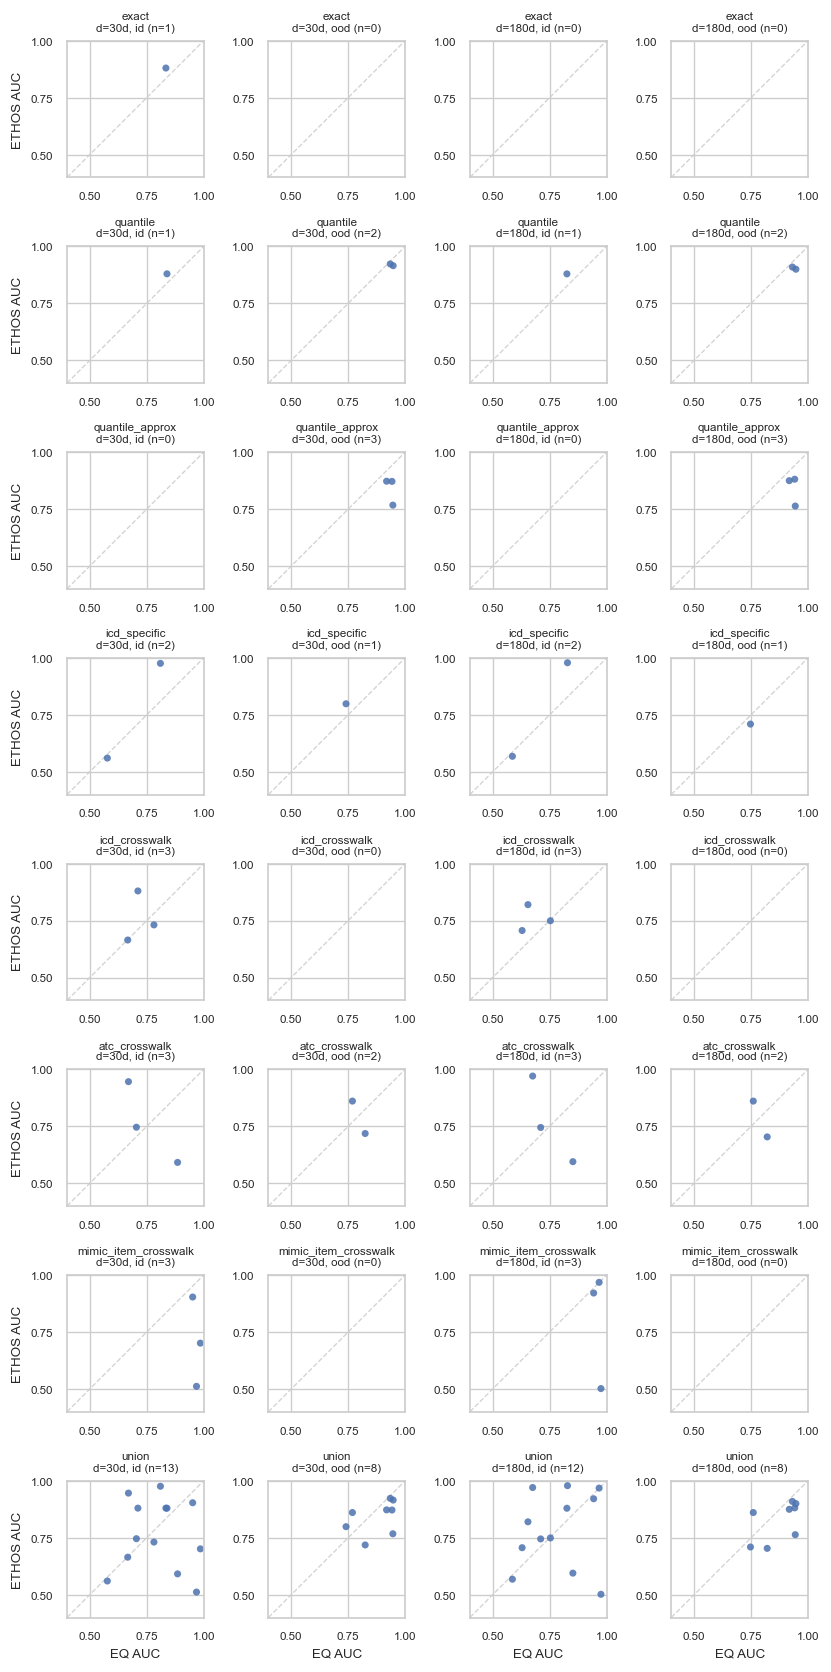

In [5]:
# Tier display order: primary-quality tiers first (exact, lab presence/decile, ICD specific/parent),
# then secondary-quality (ATC class, procedure-as-diagnosis, mimic indication proxies),
# then union as the per-code OR.
primary_tier_order = [
    'exact',
    'drop_bin',
    'quantile',
    'quantile_approx',
    'icd_specific',
    'icd_crosswalk',
    'atc_crosswalk',
    'mimic_item_crosswalk',
]
available_tiers = sorted(merged['tier'].unique().to_list())
tiers = [t for t in primary_tier_order if t in available_tiers] + (['union'] if 'union' in available_tiers else [])
durations = sorted(merged['duration_days'].unique().to_list())
buckets = ['id', 'ood']
n_cols = len(durations) * len(buckets)
fig_w = 7.0  # double-column width per CLAUDE.md
panel_w = fig_w / n_cols
fig, axes = plt.subplots(len(tiers), n_cols, figsize=(fig_w, panel_w * len(tiers)), squeeze=False)
for r, tier in enumerate(tiers):
    for cdi, d in enumerate(durations):
        for bi, b in enumerate(buckets):
            c = cdi * len(buckets) + bi
            ax = axes[r, c]
            sub = merged.filter((pl.col('tier') == tier) & (pl.col('duration_days') == d) & (pl.col('bucket') == b)).to_pandas()
            sub = sub.dropna(subset=['eq_auc', 'ethos_auc'])
            ax.plot([0.4, 1.0], [0.4, 1.0], color='lightgray', lw=0.8, ls='--', zorder=0)
            ax.scatter(sub['eq_auc'], sub['ethos_auc'], s=18, alpha=0.85, edgecolor='none')
            ax.set_xlim(0.4, 1.0); ax.set_ylim(0.4, 1.0)
            ax.set_xticks([0.5, 0.75, 1.0]); ax.set_yticks([0.5, 0.75, 1.0])
            ax.set_aspect('equal')
            ax.set_title(f'{tier}\nd={d}d, {b} (n={len(sub)})', fontsize=7)
            ax.tick_params(labelsize=7)
            if c == 0:
                ax.set_ylabel('ETHOS AUC', fontsize=8)
            if r == len(tiers) - 1:
                ax.set_xlabel('EQ AUC', fontsize=8)
plt.tight_layout()
save_fig(fig, 'ethos_vs_eq_auc_scatter')
plt.show()

## 3. Paired comparison: Wilcoxon signed-rank, EQ vs ETHOS

Pairs are matched on `(query, duration_days, bucket)`. A positive `mean_diff = ETHOS − EQ` means ETHOS wins on average; the p-value tests the null that the median difference is zero. Sample sizes are small (max n=12 at the union tier) — the test is exploratory.

In [6]:
rows = []
for tier in tiers:
    for d in durations:
        for b in buckets:
            sub = merged.filter((pl.col('tier') == tier) & (pl.col('duration_days') == d) & (pl.col('bucket') == b)).to_pandas()
            sub = sub.dropna(subset=['eq_auc', 'ethos_auc'])
            n = len(sub)
            row = {'tier': tier, 'duration_days': d, 'bucket': b, 'n': n}
            if n >= 1:
                row['mean_eq'] = float(sub['eq_auc'].mean())
                row['mean_ethos'] = float(sub['ethos_auc'].mean())
                row['mean_diff'] = float((sub['ethos_auc'] - sub['eq_auc']).mean())
            else:
                row.update({'mean_eq': np.nan, 'mean_ethos': np.nan, 'mean_diff': np.nan})
            if n >= 2:
                try:
                    row['p_value'] = float(wilcoxon(sub['ethos_auc'], sub['eq_auc']).pvalue)
                except ValueError:
                    row['p_value'] = np.nan
            else:
                row['p_value'] = np.nan
            rows.append(row)
stats_df = pd.DataFrame(rows).sort_values(['tier', 'duration_days', 'bucket']).reset_index(drop=True)
save_tbl(stats_df, 'ethos_vs_eq_per_tier_stats')
stats_df

,tier,duration_days,bucket,n,mean_eq,mean_ethos,mean_diff,p_value
0,atc_crosswalk,30,id,3,0.753243,0.761147,0.007904,1.000000
1,atc_crosswalk,30,ood,2,0.796585,0.789535,-0.007050,1.000000
2,atc_crosswalk,180,id,3,0.746055,0.770063,0.024007,0.750000
3,atc_crosswalk,180,ood,2,0.790207,0.782079,-0.008128,1.000000
4,exact,30,id,1,0.834075,0.879992,0.045917,NaN
5,exact,30,ood,0,NaN,NaN,NaN,NaN
6,exact,180,id,0,NaN,NaN,NaN,NaN
7,exact,180,ood,0,NaN,NaN,NaN,NaN
8,icd_crosswalk,30,id,3,0.719764,0.758582,0.038817,1.000000
9,icd_crosswalk,30,ood,0,NaN,NaN,NaN,NaN


In [7]:
print('Aggregated across (duration, bucket) per tier:')
agg_rows = []
for tier in tiers:
    sub = merged.filter(pl.col('tier') == tier).to_pandas().dropna(subset=['eq_auc', 'ethos_auc'])
    n = len(sub)
    tier_quality = sub['tier_quality'].iloc[0] if n and 'tier_quality' in sub.columns else (
        'union' if tier == 'union' else float('nan')
    )
    if n < 2:
        msg_p = 'NA'
        p_val = float('nan')
        diff = sub['ethos_auc'].mean() - sub['eq_auc'].mean() if n else float('nan')
    else:
        try:
            p_val = float(wilcoxon(sub['ethos_auc'], sub['eq_auc']).pvalue)
            msg_p = f'{p_val:.3g}'
        except ValueError:
            p_val = float('nan')
            msg_p = 'NA'
        diff = (sub['ethos_auc'] - sub['eq_auc']).mean()
    print(f'  {tier:>20s}  ({tier_quality:>9s})  n={n:3d}  mean_eq={sub["eq_auc"].mean():.3f}  mean_ethos={sub["ethos_auc"].mean():.3f}  mean_diff={diff:+.3f}  p={msg_p}')
    agg_rows.append({
        'tier': tier,
        'tier_quality': tier_quality,
        'n': n,
        'mean_eq': float(sub['eq_auc'].mean()) if n else float('nan'),
        'mean_ethos': float(sub['ethos_auc'].mean()) if n else float('nan'),
        'mean_diff': float(diff) if n else float('nan'),
        'p_value': p_val,
    })
agg_df = pd.DataFrame(agg_rows)
save_tbl(agg_df, 'ethos_vs_eq_aggregated_per_tier')
agg_df

Aggregated across (duration, bucket) per tier:
                 exact  (  primary)  n=  1  mean_eq=0.834  mean_ethos=0.880  mean_diff=+0.046  p=NA
              quantile  (  primary)  n=  6  mean_eq=0.904  mean_ethos=0.901  mean_diff=-0.003  p=1
       quantile_approx  (  primary)  n=  6  mean_eq=0.935  mean_ethos=0.839  mean_diff=-0.096  p=0.0312
          icd_specific  (  primary)  n=  6  mean_eq=0.715  mean_ethos=0.765  mean_diff=+0.050  p=0.438
         icd_crosswalk  (  primary)  n=  6  mean_eq=0.699  mean_ethos=0.759  mean_diff=+0.059  p=0.438
         atc_crosswalk  (secondary)  n= 10  mean_eq=0.767  mean_ethos=0.774  mean_diff=+0.007  p=1
  mimic_item_crosswalk  (secondary)  n=  6  mean_eq=0.965  mean_ethos=0.751  mean_diff=-0.214  p=0.0625
                 union  (secondary)  n= 41  mean_eq=0.825  mean_ethos=0.798  mean_diff=-0.027  p=0.396


,tier,tier_quality,n,mean_eq,mean_ethos,mean_diff,p_value
0,exact,primary,1,0.834075,0.879992,0.045917,NaN
1,quantile,primary,6,0.904178,0.901190,-0.002988,1.000000
2,quantile_approx,primary,6,0.935023,0.838569,-0.096455,0.031250
3,icd_specific,primary,6,0.714988,0.765152,0.050164,0.437500
4,icd_crosswalk,primary,6,0.699467,0.758567,0.059099,0.437500
5,atc_crosswalk,secondary,10,0.767148,0.773686,0.006538,1.000000
6,mimic_item_crosswalk,secondary,6,0.965192,0.751278,-0.213914,0.062500
7,union,secondary,41,0.824845,0.797692,-0.027153,0.396364


## 3a. Primary vs secondary tier-quality split (Phase 10 headline)

The headline ETHOS-vs-EQ comparison aggregates each tier-quality bucket into a single Wilcoxon test on `(query, duration_days, bucket)` cells. `primary` rows are tiers where ETHOS commits to the most-specific encoding the vocabulary supports; `secondary` rows are best-effort proxies (ATC level 2, procedure-as-diagnosis, indication-proxy lab item-ids, `TIMELINE//START -> HOSPITAL_ADMISSION`). The `union` row is reported separately as the per-code OR over all tiers.

In [8]:
quality_rows = []
non_union = merged.filter(pl.col('tier') != 'union')
for quality in ['primary', 'secondary']:
    sub = (
        non_union.filter(pl.col('tier_quality') == quality)
        .to_pandas()
        .dropna(subset=['eq_auc', 'ethos_auc'])
    )
    n = len(sub)
    if n < 2:
        msg_p = 'NA'
        p_val = float('nan')
        diff = sub['ethos_auc'].mean() - sub['eq_auc'].mean() if n else float('nan')
    else:
        try:
            p_val = float(wilcoxon(sub['ethos_auc'], sub['eq_auc']).pvalue)
            msg_p = f'{p_val:.3g}'
        except ValueError:
            p_val = float('nan')
            msg_p = 'NA'
        diff = (sub['ethos_auc'] - sub['eq_auc']).mean()
    quality_rows.append({
        'tier_quality': quality,
        'n': n,
        'n_unique_codes': sub['query'].nunique() if n else 0,
        'mean_eq': float(sub['eq_auc'].mean()) if n else float('nan'),
        'mean_ethos': float(sub['ethos_auc'].mean()) if n else float('nan'),
        'mean_diff': float(diff) if n else float('nan'),
        'p_value': p_val,
    })

union_sub = merged.filter(pl.col('tier') == 'union').to_pandas().dropna(subset=['eq_auc', 'ethos_auc'])
n_u = len(union_sub)
if n_u >= 2:
    try:
        p_u = float(wilcoxon(union_sub['ethos_auc'], union_sub['eq_auc']).pvalue)
    except ValueError:
        p_u = float('nan')
    diff_u = (union_sub['ethos_auc'] - union_sub['eq_auc']).mean()
else:
    p_u = float('nan')
    diff_u = float('nan')
quality_rows.append({
    'tier_quality': 'union',
    'n': n_u,
    'n_unique_codes': union_sub['query'].nunique() if n_u else 0,
    'mean_eq': float(union_sub['eq_auc'].mean()) if n_u else float('nan'),
    'mean_ethos': float(union_sub['ethos_auc'].mean()) if n_u else float('nan'),
    'mean_diff': float(diff_u) if n_u else float('nan'),
    'p_value': p_u,
})
quality_df = pd.DataFrame(quality_rows)
save_tbl(quality_df, 'ethos_vs_eq_aggregated_by_tier_quality')
quality_df

,tier_quality,n,n_unique_codes,mean_eq,mean_ethos,mean_diff,p_value
0,primary,23,12,0.825650,0.815689,-0.009961,0.427418
1,secondary,18,9,0.823817,0.774697,-0.049120,0.550873
2,union,41,21,0.824845,0.797692,-0.027153,0.396364


## Win rate vs ETHOS (eps=0.01)

Pair granularity matches the Wilcoxon table above: one pair per `(query, duration_days, bucket)` cell within each tier. For each pair we compare `eq_auc` to `ethos_auc` with an eps=0.01 tie band:

- **EQ win** if `eq_auc - ethos_auc > 0.01`
- **ETHOS win** if `ethos_auc - eq_auc > 0.01`
- **tie** otherwise (`|eq_auc - ethos_auc| <= 0.01`)

The headline number is **EQ-centric**: `win_rate_eq = wins_eq / (wins_eq + wins_ethos + ties)`. Ties count toward the denominator so a tier with many near-equal pairs cannot be inflated by either side.

In [9]:
WIN_EPS = 0.01


def win_counts(eq: pd.Series, ethos: pd.Series, eps: float = WIN_EPS) -> dict:
    diff = eq - ethos
    wins_eq = int((diff > eps).sum())
    wins_ethos = int((diff < -eps).sum())
    ties = int((diff.abs() <= eps).sum())
    n = wins_eq + wins_ethos + ties
    return {
        'n': n,
        'wins_eq': wins_eq,
        'ties': ties,
        'wins_ethos': wins_ethos,
        'win_rate_eq': (wins_eq / n) if n else float('nan'),
    }


def win_status(eq: float, ethos: float, eps: float = WIN_EPS) -> str:
    if eq - ethos > eps:
        return 'EQ'
    if ethos - eq > eps:
        return 'ETHOS'
    return 'TIE'

In [10]:
win_rows = []
for tier in tiers:
    sub = merged.filter(pl.col('tier') == tier).to_pandas().dropna(subset=['eq_auc', 'ethos_auc'])
    counts = win_counts(sub['eq_auc'], sub['ethos_auc'])
    win_rows.append({'tier': tier, **counts})
win_per_tier_df = pd.DataFrame(win_rows)
save_tbl(win_per_tier_df, 'ethos_vs_eq_win_rate_per_tier')
win_per_tier_df

,tier,n,wins_eq,ties,wins_ethos,win_rate_eq
0,exact,1,0,0,1,0.000000
1,quantile,6,4,0,2,0.666667
2,quantile_approx,6,6,0,0,1.000000
3,icd_specific,6,3,0,3,0.500000
4,icd_crosswalk,6,1,2,3,0.166667
5,atc_crosswalk,10,4,0,6,0.400000
6,mimic_item_crosswalk,6,5,1,0,0.833333
7,union,41,23,3,15,0.560976


In [11]:
win_detail_rows = []
for tier in tiers:
    for d in durations:
        for b in buckets:
            sub = merged.filter(
                (pl.col('tier') == tier) & (pl.col('duration_days') == d) & (pl.col('bucket') == b)
            ).to_pandas().dropna(subset=['eq_auc', 'ethos_auc'])
            counts = win_counts(sub['eq_auc'], sub['ethos_auc'])
            win_detail_rows.append({'tier': tier, 'duration_days': d, 'bucket': b, **counts})
win_per_tier_duration_bucket_df = (
    pd.DataFrame(win_detail_rows)
    .sort_values(['tier', 'duration_days', 'bucket'])
    .reset_index(drop=True)
)
save_tbl(win_per_tier_duration_bucket_df, 'ethos_vs_eq_win_rate_per_tier_duration_bucket')
win_per_tier_duration_bucket_df

,tier,duration_days,bucket,n,wins_eq,ties,wins_ethos,win_rate_eq
0,atc_crosswalk,30,id,3,1,0,2,0.333333
1,atc_crosswalk,30,ood,2,1,0,1,0.500000
2,atc_crosswalk,180,id,3,1,0,2,0.333333
3,atc_crosswalk,180,ood,2,1,0,1,0.500000
4,exact,30,id,1,0,0,1,0.000000
5,exact,30,ood,0,0,0,0,NaN
6,exact,180,id,0,0,0,0,NaN
7,exact,180,ood,0,0,0,0,NaN
8,icd_crosswalk,30,id,3,1,1,1,0.333333
9,icd_crosswalk,30,ood,0,0,0,0,NaN


In [12]:
win_per_code_df = (
    merged.select('query', 'duration_days', 'bucket', 'tier', 'eq_auc', 'ethos_auc')
    .to_pandas()
    .dropna(subset=['eq_auc', 'ethos_auc'])
    .assign(diff=lambda df: df['eq_auc'] - df['ethos_auc'])
)
win_per_code_df['win_status'] = [
    win_status(eq, et) for eq, et in zip(win_per_code_df['eq_auc'], win_per_code_df['ethos_auc'])
]
win_per_code_df = (
    win_per_code_df
    .sort_values(['tier', 'duration_days', 'bucket', 'query'])
    .reset_index(drop=True)
)
save_tbl(win_per_code_df, 'ethos_vs_eq_win_status_per_code')
win_per_code_df

,query,duration_days,bucket,tier,eq_auc,ethos_auc,diff,win_status
0,MEDICATION//Carbidopa-Levodopa (25-100)//Admin...,30,id,atc_crosswalk,0.669771,0.945980,-0.276209,ETHOS
1,MEDICATION//START//Mupirocin Nasal Ointment 2%,30,id,atc_crosswalk,0.885333,0.591485,0.293848,EQ
2,MEDICATION//STOP//Doxycycline Hyclate,30,id,atc_crosswalk,0.704625,0.745976,-0.041351,ETHOS
3,MEDICATION//Gabapentin//Delayed Administered,30,ood,atc_crosswalk,0.768579,0.860711,-0.092131,ETHOS
4,MEDICATION//STOP//Captopril,30,ood,atc_crosswalk,0.824590,0.718359,0.106231,EQ
...,...,...,...,...,...,...,...,...
77,"LAB//224054//UNK//value_[2.0,3.0)",180,ood,union,0.943938,0.763514,0.180424,EQ
78,"LAB//224690//insp/min//value_[14.0,16.0)",180,ood,union,0.931539,0.909442,0.022096,EQ
79,"LAB//227073//mEq/L//value_[17.0,19.0)",180,ood,union,0.917641,0.874874,0.042767,EQ
80,MEDICATION//Gabapentin//Delayed Administered,180,ood,union,0.759700,0.860678,-0.100978,ETHOS


## 4. Per-code table (long form)

Every (query, duration_days, bucket, tier) cell that successfully mapped, with EQ AUC, ETHOS AUC, and the EQ source ckpt.

In [13]:
_table_cols = ['query', 'duration_days', 'bucket', 'tier', 'tier_quality', 'eq_auc', 'ethos_auc', 'eq_source', 'n_rows', 'n_positive']
_table_cols = [c for c in _table_cols if c in merged.columns]
table = (
    merged.select(_table_cols)
    .with_columns((pl.col('ethos_auc') - pl.col('eq_auc')).alias('ethos_minus_eq'))
    .sort([c for c in ['tier_quality', 'tier', 'duration_days', 'bucket', 'query'] if c in merged.columns])
)
save_tbl(table, 'ethos_vs_eq_per_code')
table.to_pandas()

,query,duration_days,bucket,tier,tier_quality,eq_auc,ethos_auc,eq_source,n_rows,n_positive,ethos_minus_eq
0,MEDS_DEATH,30,id,exact,primary,0.834075,0.879992,14-08-24,15031,7,0.045917
1,DIAGNOSIS//ICD//9//3320,30,id,icd_crosswalk,primary,0.666473,0.664635,23-43-54,15031,40,-0.001839
2,DIAGNOSIS//ICD//9//4271,30,id,icd_crosswalk,primary,0.781599,0.731068,23-43-54,15031,60,-0.050531
3,DIAGNOSIS//ICD//9//3320,180,id,icd_crosswalk,primary,0.629250,0.706374,23-43-54,10550,30,0.077123
4,DIAGNOSIS//ICD//9//4271,180,id,icd_crosswalk,primary,0.753406,0.749305,23-43-54,10550,45,-0.004101
...,...,...,...,...,...,...,...,...,...,...,...
81,"LAB//224690//insp/min//value_[14.0,16.0)",180,ood,union,secondary,0.931539,0.909442,23-43-54,10550,205,-0.022096
82,"LAB//227073//mEq/L//value_[17.0,19.0)",180,ood,union,secondary,0.917641,0.874874,23-43-54,10550,290,-0.042767
83,MEDICATION//Gabapentin//Delayed Administered,180,ood,union,secondary,0.759700,0.860678,23-43-54,10550,48,0.100978
84,MEDICATION//STOP//Captopril,180,ood,union,secondary,0.820713,0.703479,23-43-54,10550,107,-0.117234


## 5. Codes left unmapped — follow-up candidates

Sorted within family by EQ AUC (descending) so the highest-leverage targets come first: codes EQ predicts well that ETHOS currently can't be evaluated on are the ones we lose the most signal on. The `unmapped_reason` column is the natural starting point for adding the next mapping tier (e.g. ICD-9/10 ↔ ETHOS descriptive labels, drug-name ↔ ATC, etc.).

In [14]:
# Use the same fallback EQ AUC as in section 2 so unmapped DIAGNOSIS / MEDICATION codes (only in partial ckpts) still get an EQ AUC for prioritisation.
eq_for_unmapped = eq_full.rename({'query': 'code'}).select('code', 'duration_days', 'bucket', 'eq_auc')
unmapped = (
    coverage.filter(pl.col('is_unmapped'))
    .rename({'query': 'code'})
    .join(eq_for_unmapped, on='code', how='left')
    .select('family', 'code', 'duration_days', 'bucket', 'eq_auc', 'unmapped_reason')
    .unique()
    .sort(['family', 'eq_auc'], descending=[False, True])
)
print(f'{unmapped.height} unmapped (code, duration, bucket) cells')
save_tbl(unmapped, 'ethos_unmapped_followups')
unmapped.to_pandas()

38 unmapped (code, duration, bucket) cells


,family,code,duration_days,bucket,eq_auc,unmapped_reason
0,INFUSION_END,"INFUSION_END//227536//value_[6.05,8.071587)",180,ood,0.982540,ethos_token_missing/no_infusion_prefix_in_vocab
1,INFUSION_END,"INFUSION_END//227536//value_[8.071587,9.379999)",180,id,0.970442,ethos_token_missing/no_infusion_prefix_in_vocab
2,INFUSION_END,"INFUSION_END//227536//value_[8.071587,9.379999)",30,id,0.964419,ethos_token_missing/no_infusion_prefix_in_vocab
3,INFUSION_END,"INFUSION_END//227536//value_[6.05,8.071587)",30,ood,0.959858,ethos_token_missing/no_infusion_prefix_in_vocab
4,INFUSION_START,INFUSION_START//220949,30,ood,0.938852,ethos_token_missing/no_infusion_prefix_in_vocab
5,INFUSION_START,INFUSION_START//220949,180,ood,0.921055,ethos_token_missing/no_infusion_prefix_in_vocab
6,INFUSION_START,"INFUSION_START//225168//value_[284.02966,350.0)",180,id,0.916787,ethos_token_missing/no_infusion_prefix_in_vocab
7,INFUSION_START,"INFUSION_START//225168//value_[284.02966,350.0)",30,id,0.897647,ethos_token_missing/no_infusion_prefix_in_vocab
8,LAB,"LAB//51769//UNK//value_[1.88,2.29)",30,ood,NaN,value_bin_or_units_unmatched
9,LAB,"LAB//51769//UNK//value_[1.88,2.29)",180,ood,0.976378,value_bin_or_units_unmatched


In [15]:
(
    coverage.filter(pl.col('is_unmapped'))
    .group_by('unmapped_reason')
    .agg(pl.len().alias('n_codes'))
    .sort('n_codes', descending=True)
    .to_pandas()
)

,unmapped_reason,n_codes
0,value_bin_or_units_unmatched,12
1,ethos_token_missing/no_infusion_prefix_in_vocab,4
2,ethos_token_missing/no_fluid_output_prefix_in_...,3
